# ETS MARL — Q-Learning Baseline

This notebook trains and analyses a **tabular Q-learning** baseline for the EU ETS multi-agent environment, and compares it against the default-config PPO/HAPPO sweep — the comparison is the headline contribution of this notebook to **Sub-RQ 1 (simulation credibility)**.

The Q-learning agents use:
- **State discretisation**: 5 features × 3 bins = 243 discrete states
- **Action profiles**: 6 auction × 4 secondary = 24 predefined strategy templates
- **Standard Q-learning**: $\alpha=0.1$, $\gamma=0.95$, linear $\varepsilon$-decay

Crucially, the baseline trains in the **same `ETSEnvironment`** as the PPO trainer — same warm-start, same uniform-price auction, same MSR / penalty / ESG mechanisms — so reward, clearing price, compliance rate, and the anchor-invariant `quality_score` are directly comparable.

**Notebook layout.** §1–§5 setup and training. §6–§8 standalone Q-learning analysis (training curves, Q-table inspection, strategy-frequency). §9 greedy evaluation. §10 single-seed Q-learning vs PPO overlay. §11 **cross-seed default-sweep comparison (Sub-RQ 1)**. §13 summary tables and Sub-RQ 1 takeaways and takeaways.


In [ ]:
# Install notebook dependencies if needed.
# Set INSTALL_NOTEBOOK_DEPS = True (or run the cell with sklearn/imblearn missing)
# to pip-install everything in notebooks/requirements-notebooks.txt using the
# CURRENT kernel's interpreter. This is more reliable than `%pip install -r {path}`
# (IPython magics don't expand `{var}` at runtime) and works on Azure / Colab / local.
import subprocess, sys, importlib
from pathlib import Path

INSTALL_NOTEBOOK_DEPS = False  # flip to True to force-reinstall

def _find_requirements():
    req_name = "requirements-notebooks.txt"
    here = Path.cwd()
    candidates = [here / req_name, here / "notebooks" / req_name]
    candidates.extend(p / "notebooks" / req_name for p in here.parents)
    return next((p for p in candidates if p.exists()), None)

def _missing_required():
    # The notebooks rely on these — if any is missing, auto-install.
    for mod in ("numpy", "pandas", "matplotlib", "yaml", "scipy"):
        try:
            importlib.import_module(mod)
        except ImportError:
            return True
    return False

req_path = _find_requirements()
if INSTALL_NOTEBOOK_DEPS or _missing_required():
    if req_path is None:
        raise FileNotFoundError("Could not find notebooks/requirements-notebooks.txt")
    print(f"Installing notebook dependencies from: {req_path}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", str(req_path)])
else:
    print("Notebook dependencies look present; skipping install.")
    print("(Set INSTALL_NOTEBOOK_DEPS = True to force a reinstall.)")


## 1. Setup

In [1]:
import os, sys

# Navigate to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

print(f'Working directory: {os.getcwd()}')

Working directory: c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import time

from src.environment.ets_environment import ETSEnvironment
from src.agents.q_learning_agent import QLearningAgent, StateDiscretizer, ActionProfileMapper
from src.train_qlearning import train_qlearning, evaluate_qlearning, merge_configs
from src.analysis.qlearning_analysis import (
    plot_qtable_heatmaps, plot_secondary_heatmaps,
    plot_strategy_frequency, plot_reward_comparison,
    plot_price_comparison, plot_green_comparison,
    plot_compliance_comparison, load_training_log
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

print('All imports successful.')

All imports successful.


## 2. Load Configuration

In [3]:
with open('configs/default.yaml') as f:
    base_config = yaml.safe_load(f)

with open('configs/qlearning.yaml') as f:
    ql_config = yaml.safe_load(f)

config = merge_configs(base_config, ql_config)

n_agents = config['companies']['n_agents']
n_years = config['simulation']['n_years']
ql_params = config['qlearning']

print(f'Agents: {n_agents} learning + {config["companies"].get("n_bot_agents", 0)} bots')
print(f'Episode length: {n_years} years')
print(f'Q-learning: {ql_params["n_episodes"]} episodes, '
      f'alpha={ql_params["alpha"]}, gamma={ql_params["gamma"]}')
print(f'Epsilon: {ql_params["epsilon_start"]} -> {ql_params["epsilon_end"]} '
      f'over {ql_params["epsilon_decay_frac"]*100:.0f}% of training')
print(f'Reward shaping: beta={config["reward"]["shaping_beta"]}, '
      f'gamma={config["reward"]["shaping_gamma"]} '
      f'(same reward structure as PPO)')

Agents: 8 learning + 0 bots
Episode length: 12 years
Q-learning: 5000 episodes, alpha=0.1, gamma=0.95
Epsilon: 1.0 -> 0.05 over 70% of training
Reward shaping: beta=7.0, gamma=1.0 (same reward structure as PPO)


## 3. Explore the State/Action Space

Before training, let's understand how the discretizer and action profiles work.

In [4]:
# Show state space structure
disc = StateDiscretizer()
print(f'Total discrete states: {disc.N_STATES}')
print(f'Features and bin edges:')
for name, edges in disc._BINS.items():
    print(f'  {name:10s}: low <= {edges[0]:.2f} | mid <= {edges[1]:.2f} | high')

print(f'\nAction profiles:')
mapper = ActionProfileMapper()
print(f'  Auction ({mapper.N_AUCTION_PROFILES}): {mapper.auction_profile_names()}')
print(f'  Secondary ({mapper.N_SECONDARY_PROFILES}): {mapper.secondary_profile_names()}')
print(f'  Total action combinations: {mapper.N_AUCTION_PROFILES * mapper.N_SECONDARY_PROFILES}')

Total discrete states: 243
Features and bin edges:
  time      : low <= 0.33 | mid <= 0.67 | high
  price     : low <= 0.30 | mid <= 0.55 | high
  green     : low <= 0.35 | mid <= 0.65 | high
  gap       : low <= 0.10 | mid <= 0.60 | high
  cf        : low <= 0.01 | mid <= 0.20 | high

Action profiles:
  Auction (6): ['Conservative', 'Moderate', 'Aggressive', 'GreenPush', 'Financial', 'PanicBuy']
  Secondary (4): ['Hold', 'SellSurplus', 'BuyShortfall', 'AggressiveBuy']
  Total action combinations: 24


In [5]:
# Show what each auction profile produces at a reference price
env_temp = ETSEnvironment(config, seed=42)
env_temp.reset(seed=42)

ref_price = 80.0  # reference MA3 price
company = env_temp.companies[0]  # coal-heavy agent

print(f'Auction profiles at MA3 price = {ref_price} EUR/t (Agent A1: coal-heavy):')
print(f'{"Profile":<15s} {"Bid":>7s} {"Qty":>5s} {"Inv%":>5s} {"Tech":>10s}')
print('-' * 45)
for p_idx in range(6):
    action = mapper.get_auction_action(p_idx, company, ref_price, config)
    tech_idx = np.argmax(action[3:6])
    tech_names = ['onshore', 'offshore', 'solar']
    name = mapper.auction_profile_names()[p_idx]
    print(f'{name:<15s} {action[0]:7.1f} {action[1]:5.2f} {action[2]*100:5.1f} {tech_names[tech_idx]:>10s}')

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.83, A2=1.75, A3=1.64, A4=1.53, A5=0.99, A6=1.22, A7=0.77, A8=0.85
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.
Auction profiles at MA3 price = 80.0 EUR/t (Agent A1: coal-heavy):
Profile             Bid   Qty  Inv%       Tech
---------------------------------------------
Conservative       72.0  1.00   1.0      solar
Moderate           88.0  1.00   3.0      solar
Aggressive        104.0  1.50   6.0    onshore
GreenPush          96.0  1.00  20.0    onshore
Financial          64.0  0.70   0.0      solar
PanicBuy          166.5  2.00   3.0      solar


## 4. Run a Random-Policy Episode (Pre-training Baseline)

In [6]:
# Run one episode with fully random actions to establish a floor
env = ETSEnvironment(config, seed=42)
agents_random = [QLearningAgent(i, seed=42+i) for i in range(n_agents)]

obs1, _ = env.reset(seed=42)
total_rewards = np.zeros(n_agents)
prices, green_fracs = [], []

for year in range(n_years):
    price_ma3 = env._compute_price_ma3()
    
    # Phase 1 (random)
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    a1_indices = np.zeros(n_agents, dtype=int)
    for i in range(n_agents):
        action, a1_idx = agents_random[i].select_auction_action(
            obs1[i], env.companies[i], price_ma3, config, epsilon=1.0)
        auction_actions[i] = action
        a1_indices[i] = a1_idx
    
    obs2, _ = env.step_auction(auction_actions)
    
    # Phase 2 (random)
    sec_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _ = agents_random[i].select_secondary_action(
            obs2[i], env.companies[i], env._phase1_clearing_price,
            config, a1_idx=a1_indices[i], epsilon=1.0)
        sec_actions[i] = action
    
    obs1, rewards, terminated, _, info = env.step_secondary(sec_actions)
    total_rewards += rewards
    
    yl = info.get('year_log', {})
    prices.append(yl.get('clearing_price', 0))
    green_fracs.append([env.companies[i].green_frac for i in range(n_agents)])

print('Random policy episode results:')
print(f'  Total rewards: {["{:.2f}".format(r) for r in total_rewards]}')
print(f'  Final green fracs: {["{:.1f}%".format(env.companies[i].green_frac*100) for i in range(n_agents)]}')
print(f'  Price range: {min(prices):.1f} - {max(prices):.1f} EUR/t')

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.83, A2=1.75, A3=1.64, A4=1.53, A5=0.99, A6=1.22, A7=0.77, A8=0.85
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.
Random policy episode results:
  Total rewards: ['-2.86', '4.23', '1.97', '3.30', '-18.21', '1.48', '-2.91', '6.22']
  Final green fracs: ['58.8%', '71.9%', '75.1%', '72.8%', '82.1%', '91.4%', '94.7%', '100.0%']
  Price range: 45.0 - 166.5 EUR/t


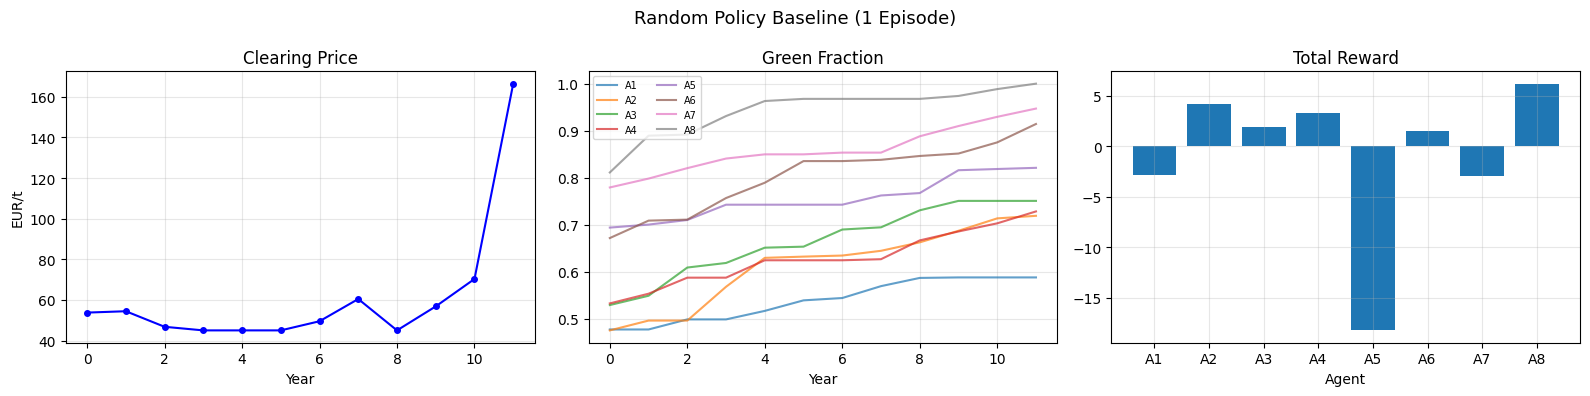

In [7]:
# Plot random episode
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(prices, 'b-o', markersize=4)
axes[0].set_title('Clearing Price')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('EUR/t')
axes[0].grid(True, alpha=0.3)

green_arr = np.array(green_fracs)
for i in range(n_agents):
    axes[1].plot(green_arr[:, i], label=f'A{i+1}', alpha=0.7)
axes[1].set_title('Green Fraction')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

axes[2].bar(range(n_agents), total_rewards)
axes[2].set_title('Total Reward')
axes[2].set_xlabel('Agent')
axes[2].set_xticks(range(n_agents))
axes[2].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
axes[2].grid(True, alpha=0.3)

plt.suptitle('Random Policy Baseline (1 Episode)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Train Q-Learning Agents

Train for 5,000 episodes (adjustable via config). This should take a few minutes.

In [8]:
SEED = 42

# Run training
trained_agents, trained_config = train_qlearning(base_config, ql_config, seed=SEED)


Q-Learning Baseline Training — seed 42
  Episodes: 5000  |  Alpha: 0.1  |  Gamma: 0.95
  Epsilon: 1.00 -> 0.05 over 3500 episodes
  Learning agents: 8  |  Bots: 0  |  Years/episode: 12
  States: 243  |  Actions: 6×4 profiles

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.83, A2=1.75, A3=1.64, A4=1.53, A5=0.99, A6=1.22, A7=0.77, A8=0.85
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.
Ep    50/5000 | eps=0.987 | price=80.0 | Q=+0.74 | elapsed=0:00:04 ETA=0:06:24
  A1: rew=  -5.88  green= 65.3%  comply= 91.8%  short=1.217Mt
  A2: rew=  -2.24  green= 65.7%  comply= 90.8%  short=3.039Mt
  A3: rew=  -7.93  green= 70.5%  comply= 85.7%  short=2.766Mt
  A4: rew=  -4.77  green= 71.4%  comply= 78.0%  sho

## 6. Training Curves

In [9]:
import glob
import re

# Resolve results directory even if Section 5 was run on another device
if 'trained_config' in globals() and isinstance(trained_config, dict):
    results_dir = trained_config.get('logging', {}).get('results_dir', 'results/qlearning/')
else:
    results_dir = 'results/qlearning/'

# Find training logs; prefer the current SEED if available
log_pattern = os.path.join(results_dir, 'ql_training_log_s*.csv')
log_candidates = glob.glob(log_pattern)

if not log_candidates:
    # Fallback: search recursively under results/
    log_candidates = glob.glob(os.path.join('results', '**', 'ql_training_log_s*.csv'), recursive=True)

if not log_candidates:
    raise FileNotFoundError(
        "No Q-learning training log found. Expected files like 'ql_training_log_s42.csv'."
    )

def _seed_from_path(path):
    m = re.search(r'ql_training_log_s(\d+)\.csv$', path.replace('\\', '/'))
    return int(m.group(1)) if m else -1

preferred_seed = globals().get('SEED', None)
if preferred_seed is not None:
    matching = [p for p in log_candidates if _seed_from_path(p) == preferred_seed]
else:
    matching = []

if matching:
    log_path = matching[0]
else:
    # Use latest modified log if preferred seed is unavailable
    log_path = max(log_candidates, key=os.path.getmtime)

ACTIVE_SEED = _seed_from_path(log_path)
SEED = ACTIVE_SEED  # keep downstream cells consistent
results_dir = os.path.dirname(log_path) or results_dir

ql_df = pd.read_csv(log_path)

print(f'Training log loaded: {log_path}')
print(f'Active seed: {ACTIVE_SEED}')
print(f'Training log: {len(ql_df)} episodes')
print(f'Columns: {list(ql_df.columns)[:10]}...')

# Optional artifact: Q-tables
qtable_candidates = []
qtable_pref = os.path.join(results_dir, f'qtables_s{ACTIVE_SEED}_final.npz')
if os.path.exists(qtable_pref):
    qtable_candidates = [qtable_pref]
else:
    qtable_candidates = glob.glob(os.path.join(results_dir, 'qtables_s*_final.npz'))

HAS_QTABLES = len(qtable_candidates) > 0
qtables = None
qtable_path = None
if HAS_QTABLES:
    qtable_path = qtable_candidates[0]
    qtables = dict(np.load(qtable_path, allow_pickle=False))
    print(f'Q-tables loaded: {qtable_path}')
else:
    print('Q-tables not found. Q-table analysis and evaluation cells will be skipped.')

# Build evaluation inputs if possible
EVAL_AGENTS = None
EVAL_CONFIG = None

if 'trained_agents' in globals() and 'trained_config' in globals():
    EVAL_AGENTS = trained_agents
    EVAL_CONFIG = trained_config
    print('Evaluation source: in-memory trained_agents/trained_config')
else:
    # Rebuild config from YAML (works when notebook restarted on another machine)
    if 'config' not in globals():
        with open('configs/default.yaml') as f:
            _base = yaml.safe_load(f)
        with open('configs/qlearning.yaml') as f:
            _ql = yaml.safe_load(f)
        config = merge_configs(_base, _ql)
    EVAL_CONFIG = config

    if HAS_QTABLES:
        n_agents_local = EVAL_CONFIG['companies']['n_agents']
        ql_params_local = EVAL_CONFIG.get('qlearning', {})
        restored_agents = [
            QLearningAgent(
                i,
                alpha=ql_params_local.get('alpha', 0.1),
                gamma=ql_params_local.get('gamma', 0.95),
                seed=ACTIVE_SEED + i,
            )
            for i in range(n_agents_local)
        ]
        for i in range(n_agents_local):
            key = f'agent_{i}'
            if key in qtables:
                restored_agents[i].q_table = qtables[key]
        EVAL_AGENTS = restored_agents
        print('Evaluation source: agents reconstructed from saved Q-tables + YAML config')

ql_df.tail(3)

Training log loaded: results/qlearning\ql_training_log_s42.csv
Active seed: 42
Training log: 5000 episodes
Columns: ['episode', 'epsilon', 'clearing_price_last', 'cap_last', 'tnac', 'ep_mean_clearing_price', 'mean_price', 'secondary_volume', 'secondary_avg_price', 'price_start']...
Q-tables loaded: results/qlearning\qtables_s42_final.npz
Evaluation source: in-memory trained_agents/trained_config


,episode,epsilon,clearing_price_last,cap_last,tnac,ep_mean_clearing_price,mean_price,secondary_volume,secondary_avg_price,price_start,...,green_frac_A8,delta_green_A8,compliance_rate_A8,shortfall_A8,penalty_A8,bid_price_A8,queue_size_A8,a1_profile_A8,a2_profile_A8,invest_cost_A8
4997,4997,0.05,93.72,11.7943,19.9500,65.06,65.06,22.9461,81.81,53.76,...,1.0000,0.0,1.000,0.0000,0.000,93.72,1,3,1,1150.348
4998,4998,0.05,75.54,11.7943,14.8576,63.63,63.63,21.0000,86.14,53.76,...,0.9799,0.0,0.917,0.6042,91.738,75.54,6,3,1,1253.974
4999,4999,0.05,88.98,11.7943,18.6517,58.18,58.18,24.0000,71.37,60.48,...,0.9726,0.0,1.000,0.0000,0.000,88.98,8,2,1,1222.353


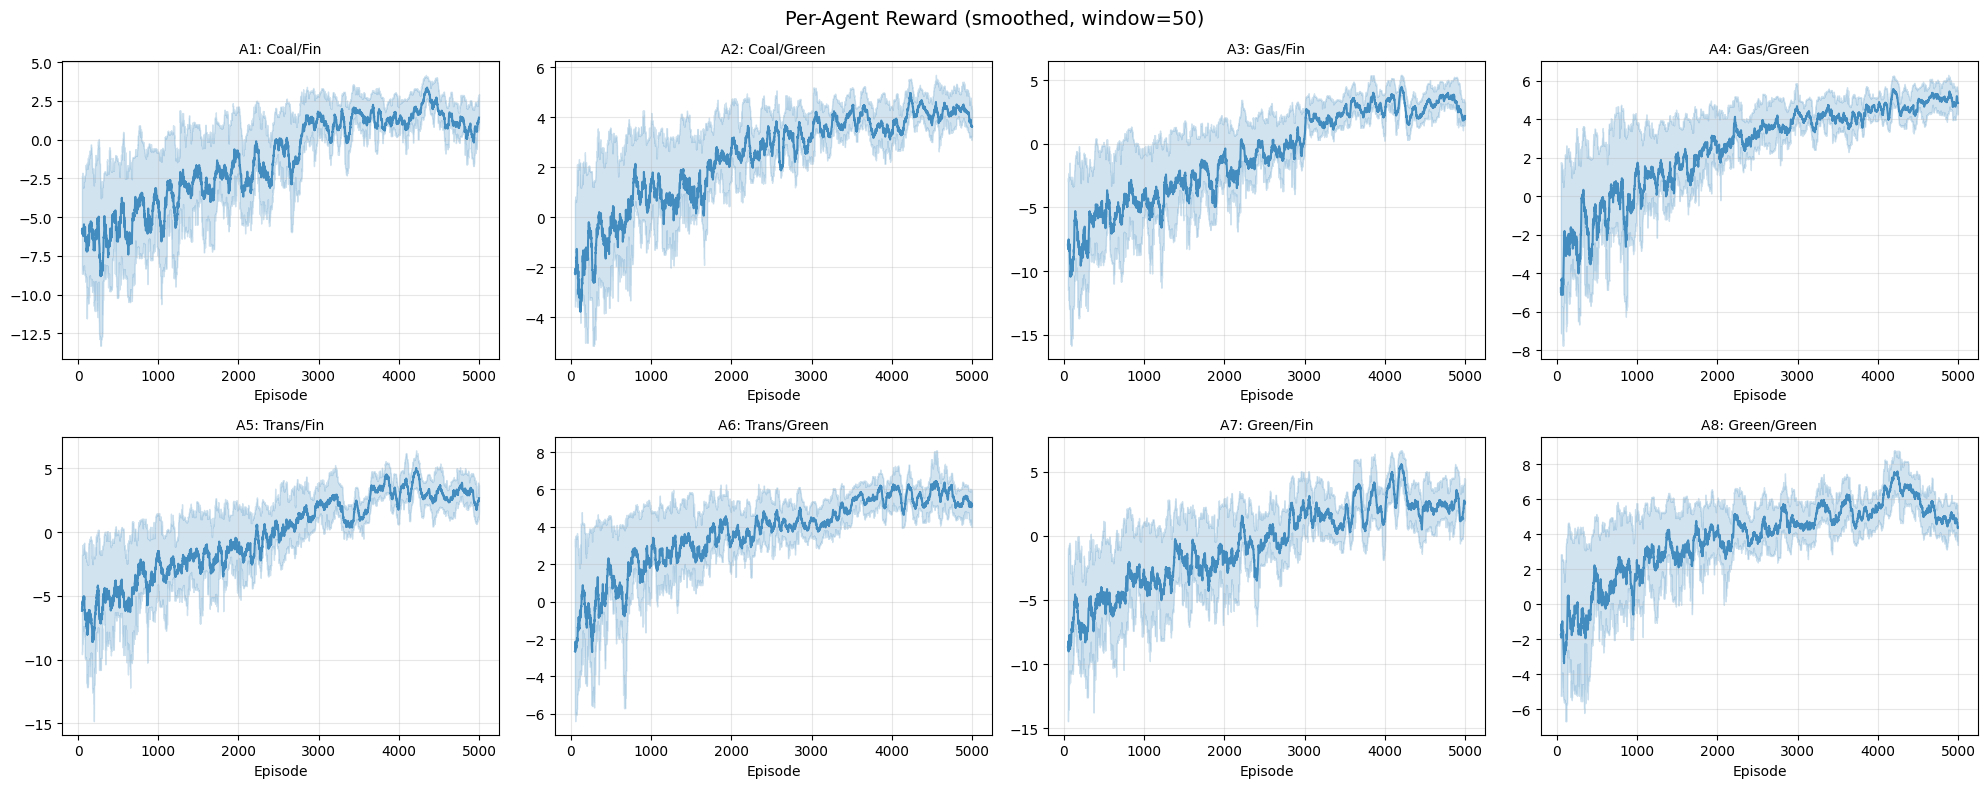

In [10]:
# Reward curves
window = 50
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f'Per-Agent Reward (smoothed, window={window})', fontsize=14)

archetypes = ['Coal/Fin', 'Coal/Green', 'Gas/Fin', 'Gas/Green',
              'Trans/Fin', 'Trans/Green', 'Green/Fin', 'Green/Green']

for i in range(n_agents):
    ax = axes[i // 4, i % 4]
    col = f'reward_A{i+1}'
    rewards = ql_df[col].astype(float).values
    smoothed = pd.Series(rewards).rolling(window).mean()
    ax.plot(smoothed, color='tab:blue', alpha=0.8)
    ax.fill_between(range(len(smoothed)),
                    pd.Series(rewards).rolling(window).quantile(0.25),
                    pd.Series(rewards).rolling(window).quantile(0.75),
                    alpha=0.2, color='tab:blue')
    ax.set_title(f'A{i+1}: {archetypes[i]}', fontsize=10)
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

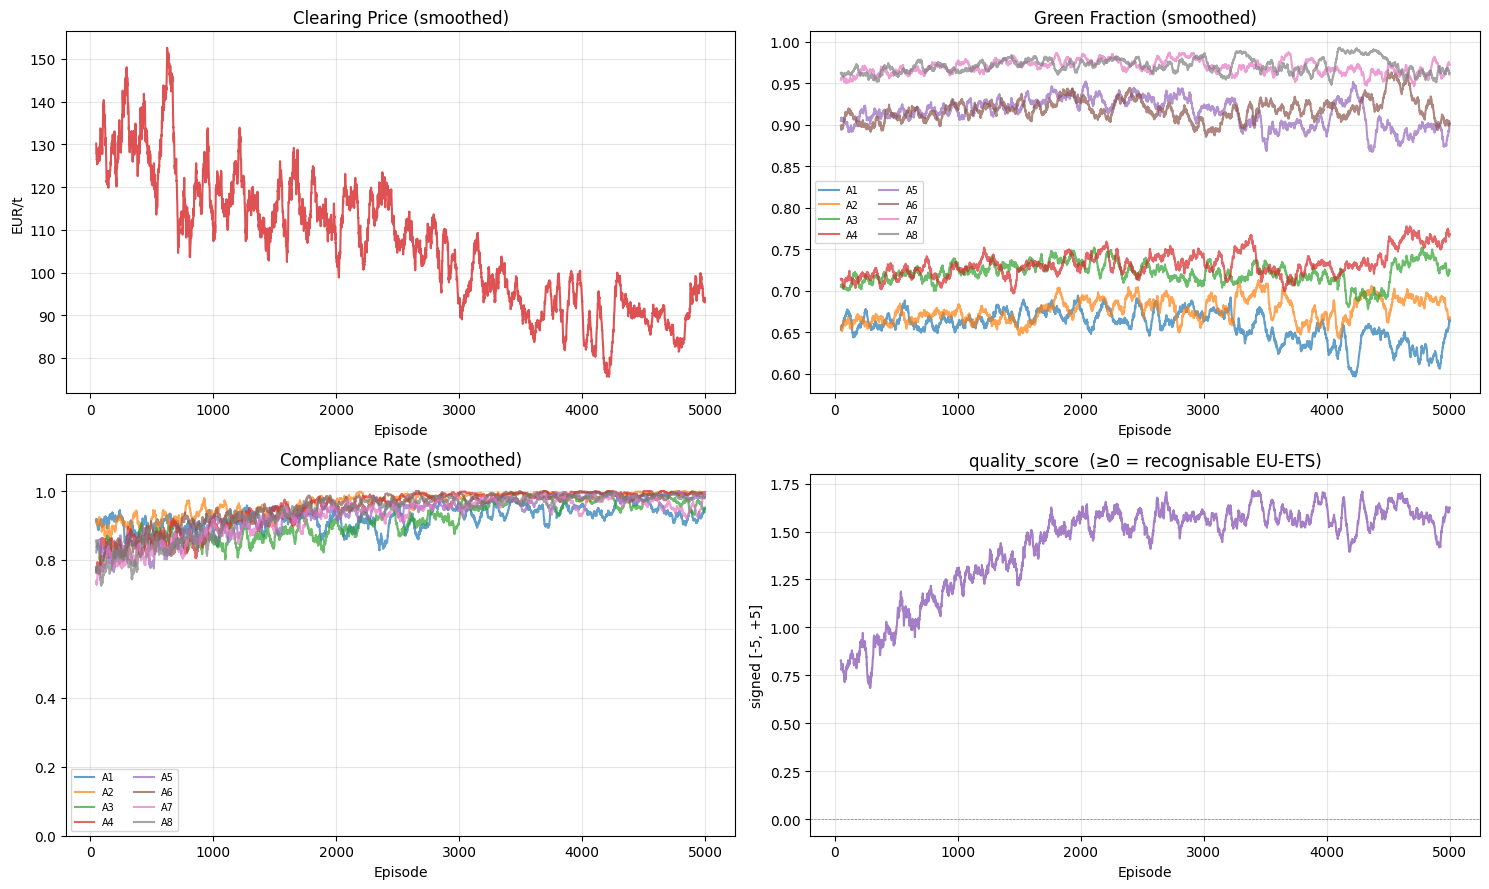

In [11]:
# Price, green fraction, compliance, and quality_score trajectories
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.ravel()

# Price
prices = ql_df['clearing_price_last'].astype(float)
axes[0].plot(prices.rolling(window).mean(), color='tab:red', alpha=0.8)
axes[0].set_title('Clearing Price (smoothed)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('EUR/t')
axes[0].grid(True, alpha=0.3)

# Green fractions per agent
for i in range(n_agents):
    gf = ql_df[f'green_frac_A{i+1}'].astype(float)
    axes[1].plot(gf.rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
axes[1].set_title('Green Fraction (smoothed)')
axes[1].set_xlabel('Episode'); axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

# Compliance rate per agent
for i in range(n_agents):
    cr = ql_df[f'compliance_rate_A{i+1}'].astype(float)
    axes[2].plot(cr.rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
axes[2].set_title('Compliance Rate (smoothed)')
axes[2].set_xlabel('Episode'); axes[2].legend(fontsize=7, ncol=2)
axes[2].set_ylim(0, 1.05); axes[2].grid(True, alpha=0.3)

# Quality score (anchor-invariant) — same metric the PPO trainer logs
if 'quality_score' in ql_df.columns:
    qs = pd.to_numeric(ql_df['quality_score'], errors='coerce')
    axes[3].plot(qs.rolling(window).mean(), color='tab:purple', alpha=0.85)
    axes[3].axhline(0, color='grey', lw=0.5, ls='--')
    axes[3].set_title('quality_score  (≥0 = recognisable EU-ETS)')
    axes[3].set_xlabel('Episode'); axes[3].set_ylabel('signed [-5, +5]')
    axes[3].grid(True, alpha=0.3)
else:
    axes[3].set_axis_off()
    axes[3].text(0.5, 0.5, 'quality_score not in CSV\n(re-run training)',
                 ha='center', va='center', transform=axes[3].transAxes)

plt.tight_layout(); plt.show()


## 7. Q-Table Analysis

In [12]:
# Load final Q-tables (already loaded in Cell 15)
if HAS_QTABLES and qtables is not None:
    print(f'Loaded Q-tables for {len(qtables)} agents from: {qtable_path}')
    for key, qt in qtables.items():
        nonzero = np.count_nonzero(qt)
        total = qt.size
        print(f'  {key}: shape={qt.shape}, '
              f'non-zero={nonzero}/{total} ({nonzero/total*100:.1f}%), '
              f'Q range=[{qt.min():.3f}, {qt.max():.3f}]')
else:
    print('No Q-tables available. Skipping Section 7 plots and top-Q analysis.')

Loaded Q-tables for 8 agents from: results/qlearning\qtables_s42_final.npz
  agent_0: shape=(243, 6, 4), non-zero=1253/5832 (21.5%), Q range=[-4.404, 1.823]
  agent_1: shape=(243, 6, 4), non-zero=1172/5832 (20.1%), Q range=[-2.120, 3.341]
  agent_2: shape=(243, 6, 4), non-zero=1417/5832 (24.3%), Q range=[-4.376, 2.954]
  agent_3: shape=(243, 6, 4), non-zero=1361/5832 (23.3%), Q range=[-2.101, 4.071]
  agent_4: shape=(243, 6, 4), non-zero=917/5832 (15.7%), Q range=[-4.920, 3.152]
  agent_5: shape=(243, 6, 4), non-zero=919/5832 (15.8%), Q range=[-1.591, 4.521]
  agent_6: shape=(243, 6, 4), non-zero=831/5832 (14.2%), Q range=[-5.488, 3.712]
  agent_7: shape=(243, 6, 4), non-zero=828/5832 (14.2%), Q range=[-1.970, 4.650]


c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\src\analysis\qlearning_analysis.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])


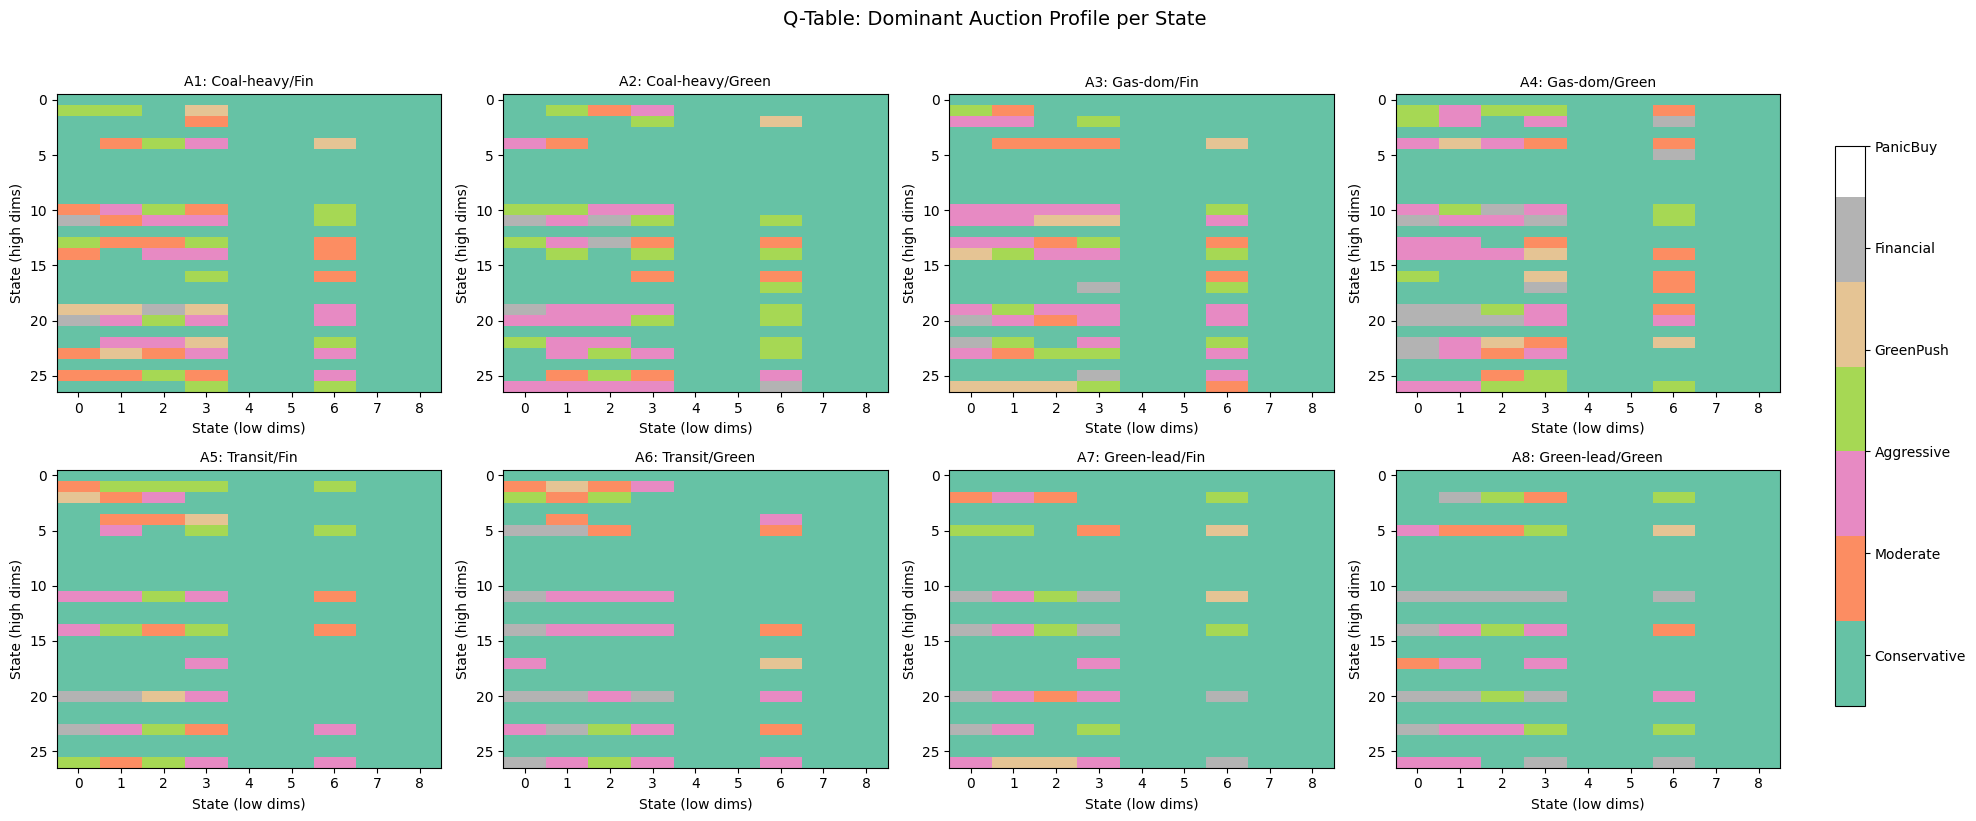

In [13]:
# Q-table heatmaps: dominant auction profile per state
if HAS_QTABLES and qtables is not None:
    plot_qtable_heatmaps(qtables, n_agents)
    plt.show()
else:
    print('Skipped: Q-tables not available.')

c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\src\analysis\qlearning_analysis.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])


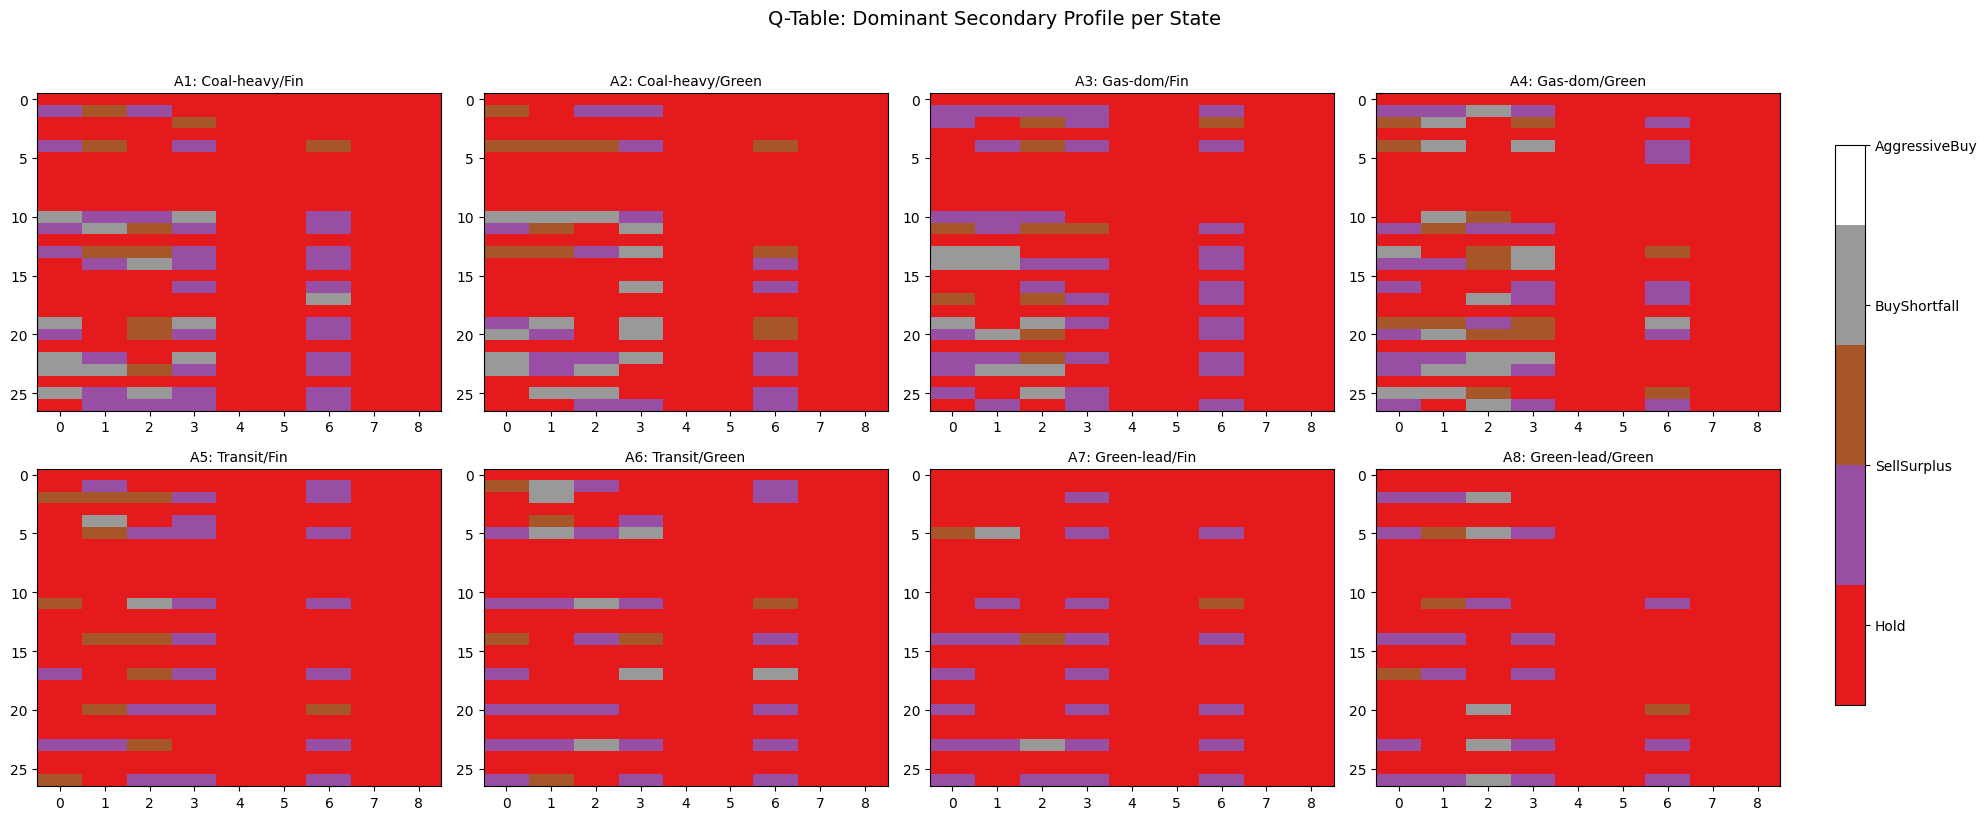

In [14]:
# Q-table heatmaps: dominant secondary profile per state
if HAS_QTABLES and qtables is not None:
    plot_secondary_heatmaps(qtables, n_agents)
    plt.show()
else:
    print('Skipped: Q-tables not available.')

In [15]:
# Top-5 Q-values per agent (works with saved Q-tables, no in-memory agents required)
if HAS_QTABLES and qtables is not None:
    a1_names = ActionProfileMapper.auction_profile_names()
    a2_names = ActionProfileMapper.secondary_profile_names()
    disc = StateDiscretizer()

    for i in range(n_agents):
        key = f'agent_{i}'
        if key not in qtables:
            print(f'\nA{i+1}: Q-table missing ({key})')
            continue

        qt = qtables[key]  # expected shape: [state, auction_profile, secondary_profile]
        k = 5
        flat = qt.reshape(-1)
        top_idx = np.argpartition(flat, -k)[-k:]
        top_idx = top_idx[np.argsort(flat[top_idx])[::-1]]

        print(f'\nA{i+1} ({archetypes[i]}) — Top 5 Q-values:')
        for idx in top_idx:
            s, a1, a2 = np.unravel_index(idx, qt.shape)
            qval = qt[s, a1, a2]
            bins = disc.index_to_bins(int(s))
            state_desc = ', '.join([['early','mid','late'][bins[0]],
                                    ['lowP','medP','highP'][bins[1]],
                                    ['dirty','mixed','green'][bins[2]],
                                    ['deficit','balanced','surplus'][bins[3]],
                                    ['noCF','someCF','heavyCF'][bins[4]]])
            print(f'  Q={qval:+.3f} | state=({state_desc}) | '
                  f'auction={a1_names[a1]} | secondary={a2_names[a2]}')
else:
    print('Skipped: Q-tables not available.')


A1 (Coal/Fin) — Top 5 Q-values:
  Q=+1.823 | state=(mid, lowP, green, surplus, noCF) | auction=GreenPush | secondary=SellSurplus
  Q=+1.753 | state=(mid, lowP, green, balanced, noCF) | auction=Aggressive | secondary=SellSurplus
  Q=+1.734 | state=(mid, lowP, green, surplus, noCF) | auction=Moderate | secondary=SellSurplus
  Q=+1.694 | state=(mid, lowP, green, surplus, noCF) | auction=GreenPush | secondary=Hold
  Q=+1.680 | state=(early, lowP, mixed, surplus, noCF) | auction=Conservative | secondary=Hold

A2 (Coal/Green) — Top 5 Q-values:
  Q=+3.341 | state=(early, lowP, mixed, surplus, noCF) | auction=Conservative | secondary=Hold
  Q=+3.307 | state=(early, lowP, mixed, surplus, noCF) | auction=Moderate | secondary=Hold
  Q=+3.305 | state=(early, lowP, mixed, surplus, noCF) | auction=Financial | secondary=Hold
  Q=+3.289 | state=(early, lowP, mixed, surplus, noCF) | auction=Moderate | secondary=BuyShortfall
  Q=+3.287 | state=(early, lowP, mixed, surplus, noCF) | auction=Moderate | se

## 8. Strategy Frequency Analysis

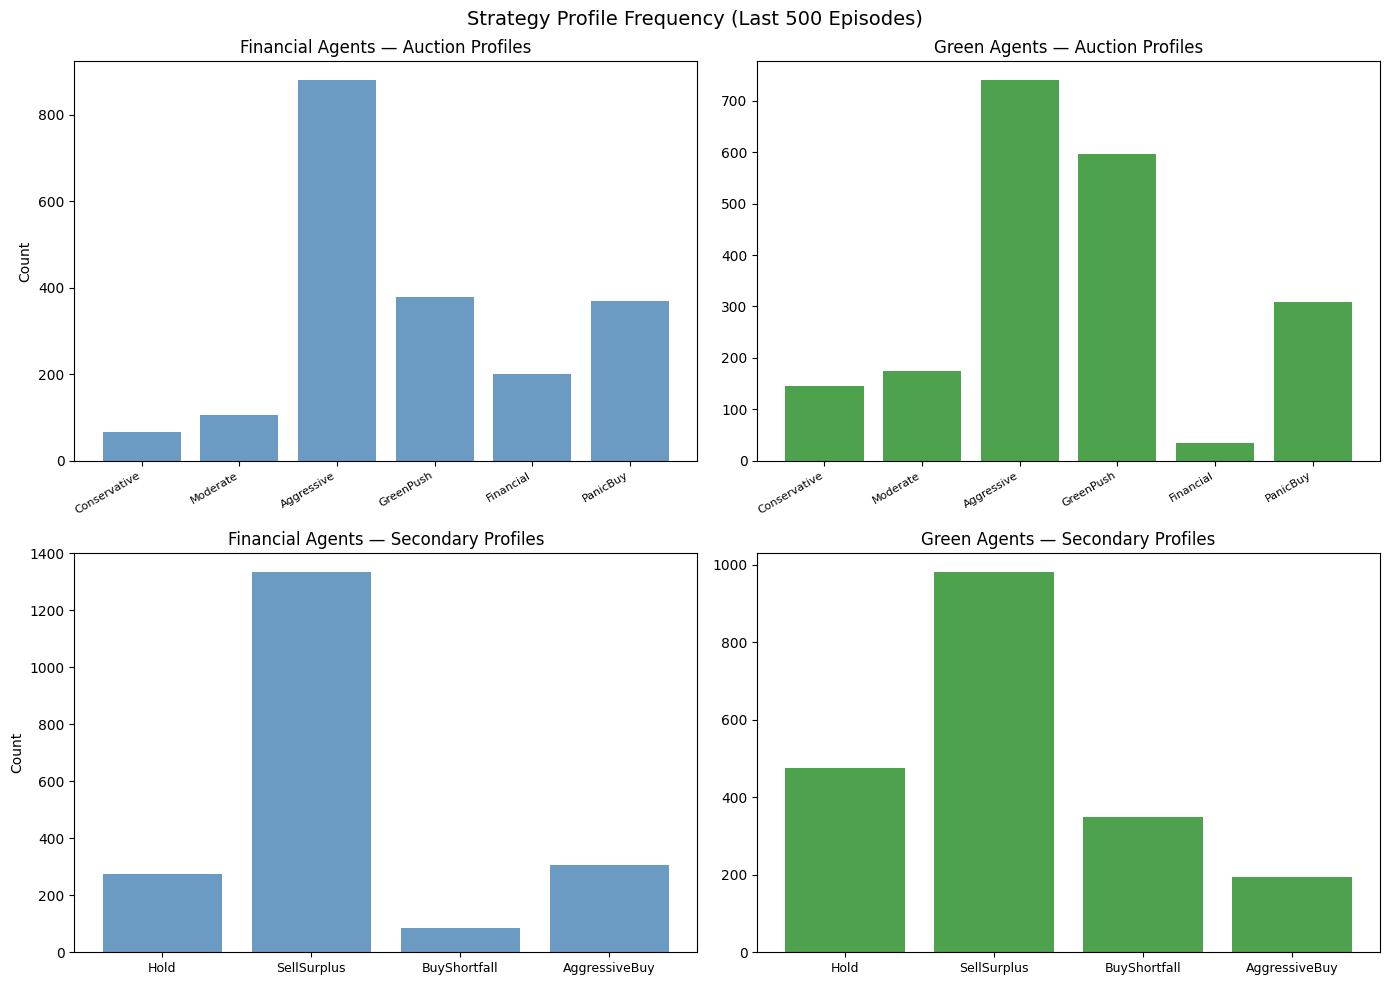

In [16]:
# Strategy frequency in last 500 episodes
plot_strategy_frequency(ql_df, n_agents, last_n=500)
plt.show()

## 9. Greedy Evaluation (100 Episodes)

In [17]:
if EVAL_AGENTS is not None and EVAL_CONFIG is not None:
    eval_results = evaluate_qlearning(
        EVAL_AGENTS, EVAL_CONFIG, seed=SEED,
        n_eval_episodes=100
    )
else:
    eval_results = None
    print('Skipped: evaluation requires trained agents or saved Q-tables.')


Q-Learning Evaluation — 100 greedy episodes (seed 42)
Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.83, A2=2.05, A3=1.41, A4=1.53, A5=1.10, A6=1.07, A7=0.83, A8=0.77
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.

Evaluation Results (mean ± std over 100 episodes):
  Avg clearing price: 59.9 ± 5.1 €/t
  Avg quality_score:  +1.52 ± 0.18
  A1: reward=+1.40±2.03  green=65.5%  comply=92.3%  short=0.305Mt
  A2: reward=+3.16±1.44  green=64.2%  comply=98.9%  short=0.060Mt
  A3: reward=+1.82±3.06  green=71.3%  comply=94.2%  short=0.951Mt
  A4: reward=+4.96±1.10  green=76.9%  comply=99.7%  short=0.014Mt
  A5: reward=+3.25±1.54  green=90.3%  comply=99.0%  short=0.033Mt
  A6: reward=+5.59±1.38  green=91.

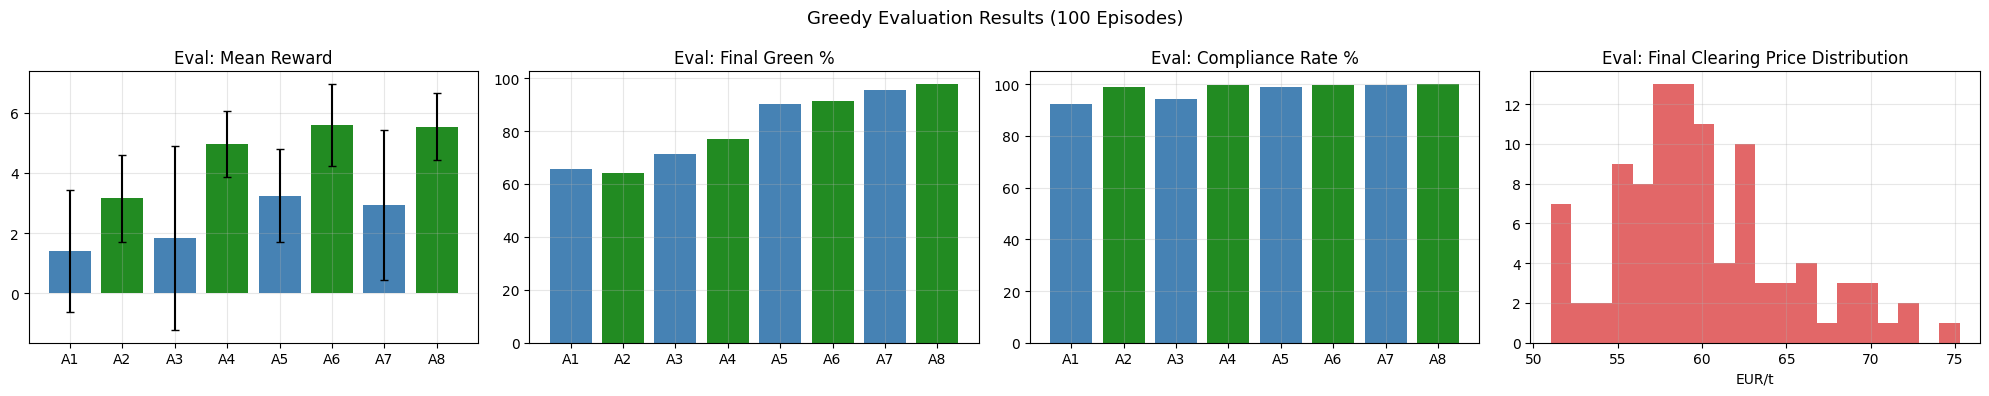

In [18]:
# Evaluation results visualization
if eval_results is not None:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Rewards
    mean_rew = eval_results['rewards'].mean(axis=0)
    std_rew = eval_results['rewards'].std(axis=0)
    axes[0].bar(range(n_agents), mean_rew, yerr=std_rew, capsize=3,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[0].set_title('Eval: Mean Reward')
    axes[0].set_xticks(range(n_agents))
    axes[0].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[0].grid(True, alpha=0.3)

    # Green fracs
    mean_gf = eval_results['green_fracs'].mean(axis=0)
    axes[1].bar(range(n_agents), mean_gf * 100,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[1].set_title('Eval: Final Green %')
    axes[1].set_xticks(range(n_agents))
    axes[1].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[1].grid(True, alpha=0.3)

    # Compliance
    mean_comp = eval_results['compliance'].mean(axis=0)
    axes[2].bar(range(n_agents), mean_comp * 100,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[2].set_title('Eval: Compliance Rate %')
    axes[2].set_xticks(range(n_agents))
    axes[2].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[2].set_ylim(0, 105)
    axes[2].grid(True, alpha=0.3)

    # Price distribution
    axes[3].hist(eval_results['prices'], bins=20, color='tab:red', alpha=0.7)
    axes[3].set_title('Eval: Final Clearing Price Distribution')
    axes[3].set_xlabel('EUR/t')
    axes[3].grid(True, alpha=0.3)

    plt.suptitle('Greedy Evaluation Results (100 Episodes)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Skipped: eval_results is not available.')

## 10. Comparison with PPO/HAPPO (if available)

Load PPO training logs and overlay the learning curves.

In [19]:
# Try to load PPO results for comparison
ppo_dir = 'results/'
ppo_log_path = os.path.join(ppo_dir, f'training_log_s{SEED}.csv')

if os.path.exists(ppo_log_path):
    ppo_df = pd.read_csv(ppo_log_path)
    print(f'PPO log loaded: {len(ppo_df)} episodes')
    HAS_PPO = True
else:
    print(f'PPO log not found at {ppo_log_path} - comparison plots will show Q-learning only.')
    print('Run PPO training first, then re-run this cell.')
    ppo_df = None
    HAS_PPO = False

PPO log loaded: 809 episodes


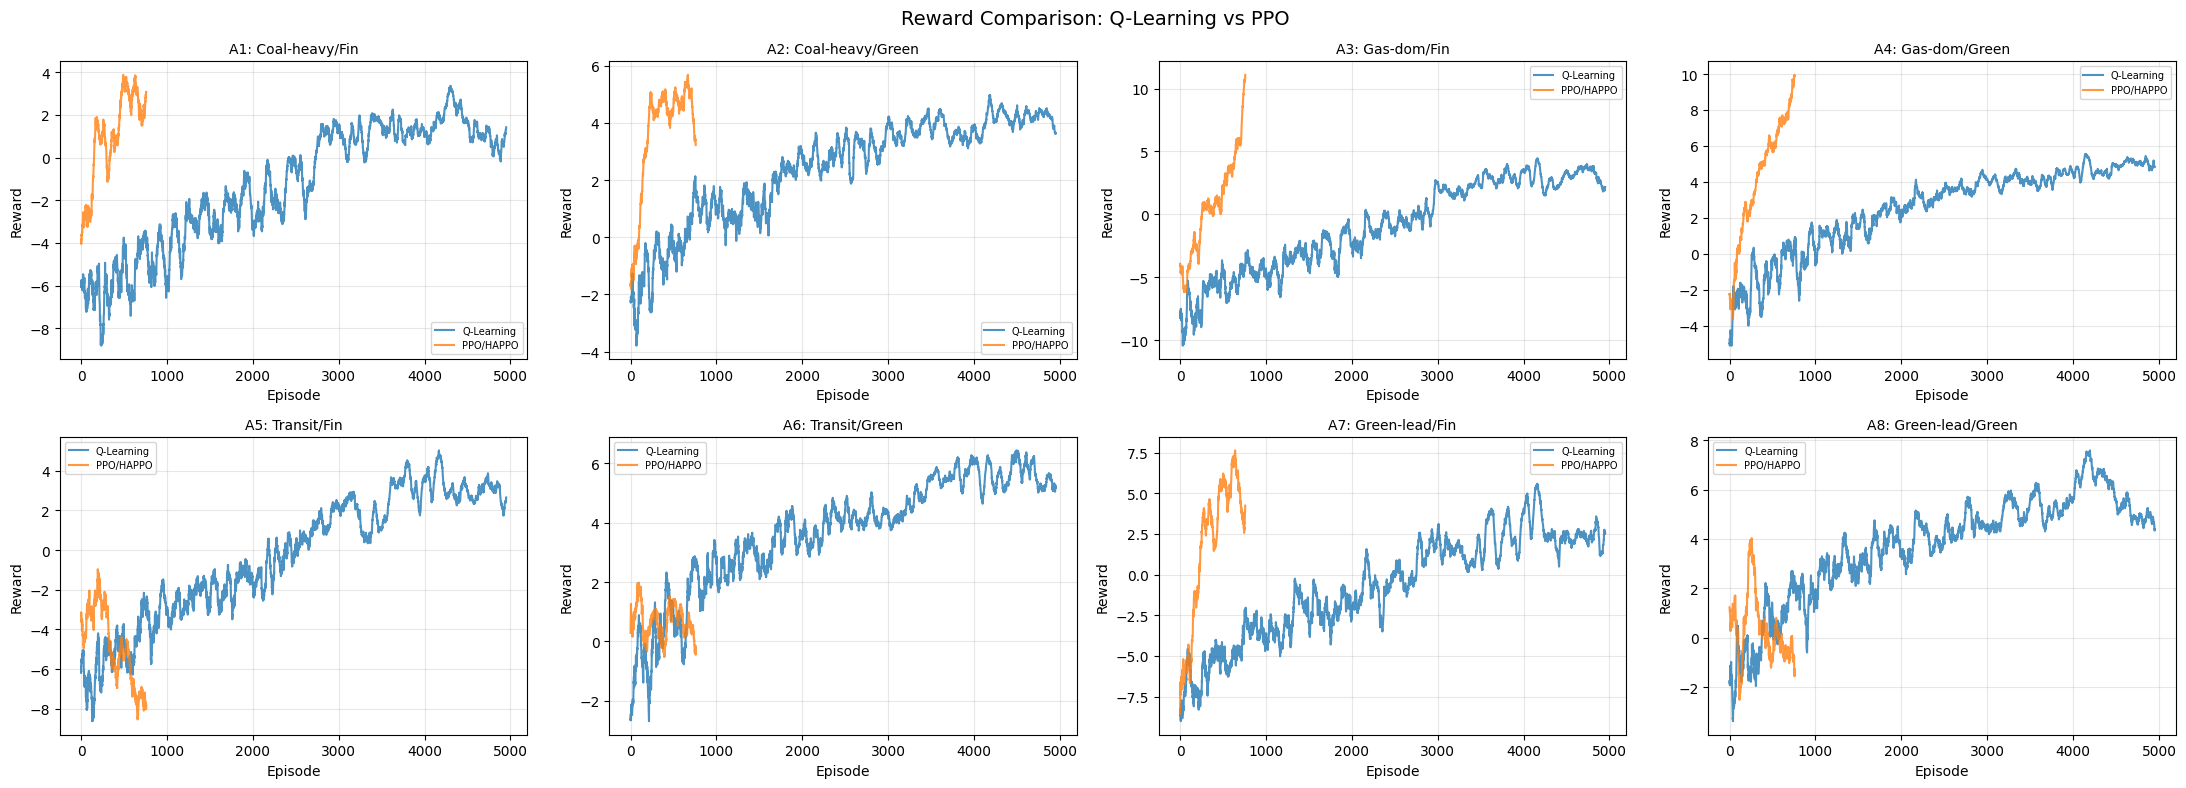

In [20]:
# Reward comparison
plot_reward_comparison(ql_df, ppo_df, n_agents)
plt.show()

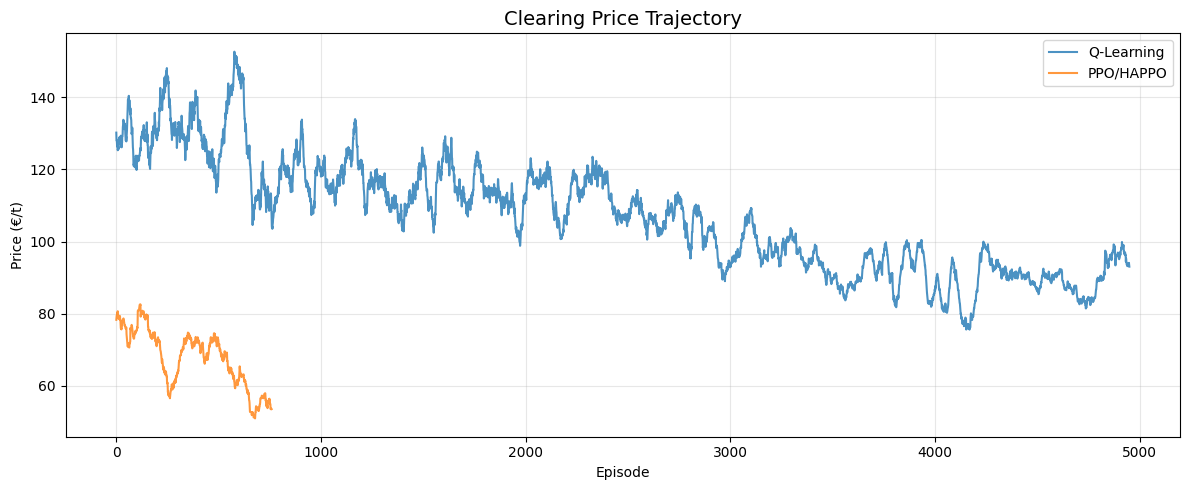

In [21]:
# Price comparison
plot_price_comparison(ql_df, ppo_df)
plt.show()

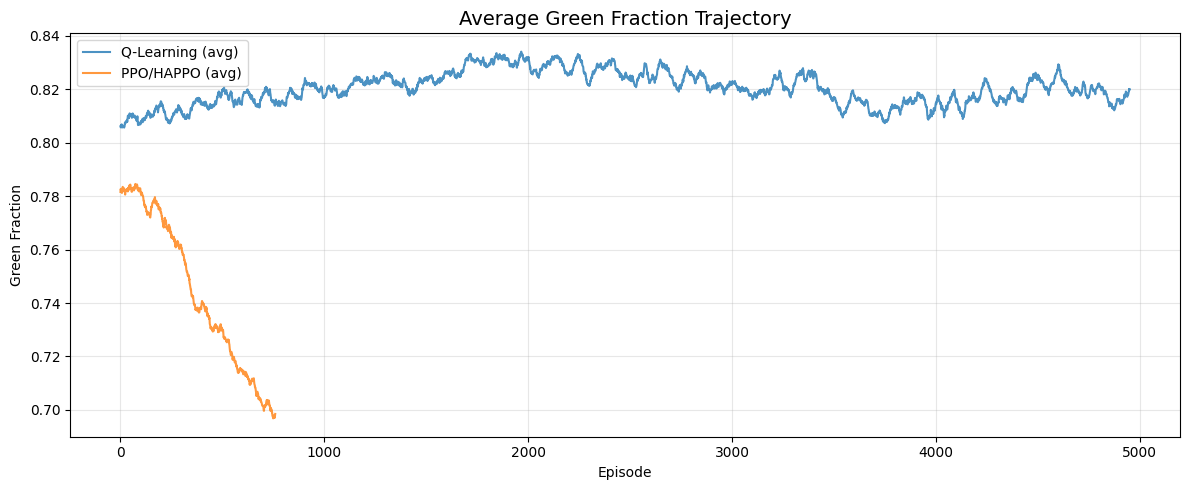

In [22]:
# Green fraction comparison
plot_green_comparison(ql_df, ppo_df, n_agents)
plt.show()

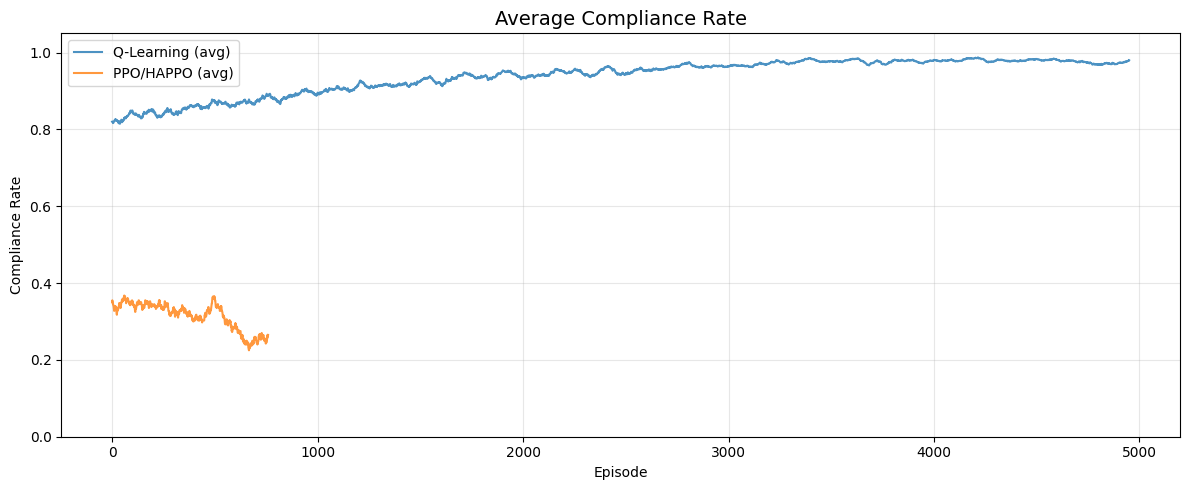

In [23]:
# Compliance comparison
plot_compliance_comparison(ql_df, ppo_df, n_agents)
plt.show()

## 11. Single-seed summary statistics

In [24]:
# Final summary table
last_500 = ql_df.tail(500)

summary_data = []
for i in range(n_agents):
    row = {
        'Agent': f'A{i+1}',
        'Archetype': archetypes[i],
        'Avg Reward': last_500[f'reward_A{i+1}'].astype(float).mean(),
        'Final Green %': last_500[f'green_frac_A{i+1}'].astype(float).mean() * 100,
        'Compliance %': last_500[f'compliance_rate_A{i+1}'].astype(float).mean() * 100,
        'Avg Shortfall': last_500[f'shortfall_A{i+1}'].astype(float).mean(),
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print('Q-Learning Performance (last 500 training episodes):')
print(summary_df.to_string(index=False, float_format='%.2f'))

if HAS_PPO:
    print('\n--- For comparison, PPO (last 500 episodes): ---')
    ppo_last = ppo_df.tail(500)
    for i in range(n_agents):
        col_r = f'reward_A{i+1}'
        col_g = f'green_frac_A{i+1}'
        if col_r in ppo_last.columns:
            ppo_rew = ppo_last[col_r].astype(float).mean()
            ppo_gf = ppo_last[col_g].astype(float).mean() * 100 if col_g in ppo_last.columns else 0
            print(f'  A{i+1}: reward={ppo_rew:.2f}, green={ppo_gf:.1f}%')

Q-Learning Performance (last 500 training episodes):
Agent   Archetype  Avg Reward  Final Green %  Compliance %  Avg Shortfall
   A1    Coal/Fin        1.02          63.09         93.67           0.69
   A2  Coal/Green        4.21          68.85         99.58           0.03
   A3     Gas/Fin        3.18          73.49         97.14           0.23
   A4   Gas/Green        5.02          76.27         99.38           0.02
   A5   Trans/Fin        2.89          89.09         98.62           0.06
   A6 Trans/Green        5.62          92.58         98.85           0.04
   A7   Green/Fin        2.32          96.42         95.62           0.13
   A8 Green/Green        5.03          96.27         98.37           0.05

--- For comparison, PPO (last 500 episodes): ---
  A1: reward=2.02, green=58.6%
  A2: reward=4.61, green=60.3%
  A3: reward=3.43, green=64.0%
  A4: reward=6.62, green=64.5%
  A5: reward=-6.09, green=77.9%
  A6: reward=0.54, green=78.2%
  A7: reward=4.58, green=87.6%
  A8: reward=

## 12. Sub-RQ 1 — Q-learning vs the default-config PPO sweep

**Sub-RQ 1 (simulation credibility).** *What environment and algorithm design choices are required to build a stable and behaviourally credible simulation of a carbon market?* The two operational claims we want to defend are:

* **RQ 1.a — convergence.** Agents converge to stable policies within a recognisable horizon.
* **RQ 1.b — reproducibility.** Findings replicate across seeds; cross-seed noise stays bounded.

Q-learning's role here is **as a floor**, not a contender. Tabular Q-learning runs in the *same* environment as PPO — same auction, same MSR, same warm-start — but compresses observations to 243 discrete states and the action space to 24 hand-coded profiles. If an environment is too simple, both algorithms succeed and the credibility of the PPO result is unclear. If the environment is too pathological, neither succeeds. The **gap** between Q-learning and PPO on the cross-seed metrics below is what tells us the simulation is non-trivial *and* solvable — i.e. credible.

Concretely, this section:
1. Loads the default-config PPO sweep (`results/sweeps/default_seeds/default/training_log_s*.csv`).
2. Loads all available Q-learning seeds (`results/qlearning/ql_training_log_s*.csv`).
3. Builds **cross-seed fan charts** for the four headline metrics: clearing price, compliance rate, mean    green fraction, and `quality_score`.
4. Reports a small **convergence-plateau** check (rolling-mean tolerance band, à la C1 in the data-science    plan).
5. Tabulates **converged-window** mean ± std for both algorithms side by side.


In [25]:
# 12.1  Locate sweep + Q-learning logs
import glob, re

# Default-config PPO sweep — see configs/sweeps/default_seeds.yaml
SWEEP_DIR_CANDIDATES = [
    'results/sweeps/default',                   # user's actual on-disk layout (preset)
    'results/sweeps/default_seeds/default',     # canonical sweep output
    'results/sweeps/default_seeds',             # fallback if variants are flattened
    'results',                                  # fallback: any training_log_s*.csv under results/
]

def _seed_from(path, prefix):
    m = re.search(rf'{re.escape(prefix)}_s(\d+)\.csv$', path.replace('\\', '/'))
    return int(m.group(1)) if m else None

ppo_logs = {}
for d in SWEEP_DIR_CANDIDATES:
    if not os.path.isdir(d):
        continue
    paths = sorted(glob.glob(os.path.join(d, 'training_log_*s*.csv')))
    for p in paths:
        # Match both `training_log_s{seed}.csv` and `training_log_<tag>_s{seed}.csv`.
        m = re.search(r'training_log(?:_[^/]*?)?_s(\d+)\.csv$', p.replace('\\', '/'))
        if m is None:
            continue
        s = int(m.group(1))
        if s not in ppo_logs:
            ppo_logs[s] = p
    if ppo_logs:
        break

ql_paths = sorted(glob.glob('results/qlearning/ql_training_log_s*.csv'))
ql_logs = {_seed_from(p, 'ql_training_log'): p for p in ql_paths
           if _seed_from(p, 'ql_training_log') is not None}

print(f'Q-learning seeds   ({len(ql_logs):2d}): {sorted(ql_logs)}')
print(f'PPO sweep seeds    ({len(ppo_logs):2d}): {sorted(ppo_logs)}')

HAS_SWEEP = len(ppo_logs) >= 2 and len(ql_logs) >= 1
if not HAS_SWEEP:
    print('\nSkipping cross-seed comparison.\n'
          'Run:  python scripts/sweep.py --spec configs/sweeps/default_seeds.yaml\n'
          'and:  python src/train_qlearning.py --seeds 42 123 456')


Q-learning seeds   ( 1): [42]
PPO sweep seeds    ( 9): [42, 111, 123, 124, 421, 520, 620, 777, 923]


In [26]:
# 12.2  Cross-seed loader — pulls the four credibility metrics into a tidy long frame
if HAS_SWEEP:
    PPO_METRICS = {
        'clearing_price':  ['ep_mean_clearing_price', 'clearing_price_last'],
        'compliance_rate': None,   # mean over agent compliance_rate_A* / shortfall_A*
        'green_frac':      None,   # mean over agent green_frac_A*
        'quality_score':   ['quality_score'],
    }

    def _agent_mean(df, prefix, n_total):
        cols = [f'{prefix}_A{i+1}' for i in range(n_total) if f'{prefix}_A{i+1}' in df.columns]
        if not cols:
            return None
        return df[cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)

    def _ppo_compliance(df, n_total):
        cols = [f'compliance_rate_A{i+1}' for i in range(n_total) if f'compliance_rate_A{i+1}' in df.columns]
        if cols:
            return df[cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
        # Fallback: derive from shortfall (PPO log records shortfall, not compliance_rate, by default)
        sf = [f'shortfall_A{i+1}' for i in range(n_total) if f'shortfall_A{i+1}' in df.columns]
        if not sf:
            return None
        return (df[sf].apply(pd.to_numeric, errors='coerce') < 1e-6).mean(axis=1)

    def _series(df, metric, n_total):
        if metric == 'compliance_rate':
            return _ppo_compliance(df, n_total)
        if metric == 'green_frac':
            return _agent_mean(df, 'green_frac', n_total)
        for col in (PPO_METRICS[metric] or []):
            if col in df.columns:
                return pd.to_numeric(df[col], errors='coerce')
        return None

    n_total_cfg = config['companies']['n_agents'] + config['companies'].get('n_bot_agents', 0)

    def _stack(logs):
        """Return dict[metric] -> DataFrame with columns = seeds and rows = episode index."""
        out = {m: {} for m in PPO_METRICS}
        for seed, path in sorted(logs.items()):
            df = pd.read_csv(path)
            for m in PPO_METRICS:
                s = _series(df, m, n_total_cfg)
                if s is not None:
                    out[m][seed] = s.reset_index(drop=True)
        return {m: pd.DataFrame(d) for m, d in out.items() if d}

    ppo_stacks = _stack(ppo_logs)
    ql_stacks  = _stack(ql_logs)
    print({m: f'{ppo_stacks[m].shape} ppo / '
              f'{ql_stacks.get(m, pd.DataFrame()).shape} ql' for m in ppo_stacks})


{'clearing_price': '(120000, 9) ppo / (5000, 1) ql', 'compliance_rate': '(120000, 9) ppo / (5000, 1) ql', 'green_frac': '(120000, 9) ppo / (5000, 1) ql'}


In [ ]:
# 12.3  Fan charts on a SHARED training-progress axis [0, 1].
# Q-learning typically trains for 5k–10k episodes while HAPPO runs 100k;
# plotting both on episode-index would dwarf the Q-learning curve.
# Instead, each seed is rebinned onto 50 evenly-spaced training-progress
# bins, then averaged across seeds. The result is apples-to-apples even
# when the absolute episode budgets differ by 10–100×.
if HAS_SWEEP:
    N_BINS = 50

    def _band_progress(stack_df, n_bins=N_BINS):
        """Return (centers, mean_across_seeds, std_across_seeds) on [0,1]."""
        if stack_df is None or stack_df.empty:
            return None
        bins = np.linspace(0.0, 1.0, n_bins + 1)
        centers = 0.5 * (bins[:-1] + bins[1:])
        per_seed = []
        for col in stack_df.columns:
            s = pd.to_numeric(stack_df[col], errors='coerce').dropna().values
            if len(s) < 2:
                continue
            progress = np.linspace(0.0, 1.0, len(s))
            idx = np.clip(np.digitize(progress, bins) - 1, 0, n_bins - 1)
            binned = pd.Series(s).groupby(idx).mean()
            binned = binned.reindex(range(n_bins)).interpolate(limit_direction='both')
            per_seed.append(binned.values)
        if not per_seed:
            return None
        M = np.vstack(per_seed)
        return centers, np.nanmean(M, axis=0), np.nanstd(M, axis=0)

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.ravel()
    metric_titles = {
        'clearing_price':  'Mean clearing price (EUR/t)',
        'compliance_rate': 'Compliance rate (mean across agents)',
        'green_frac':      'Green fraction (mean across agents)',
        'quality_score':   'quality_score  (anchor-invariant, signed)',
    }
    n_ppo_eps = int(np.mean([d.shape[0] for d in ppo_stacks.values()])) if ppo_stacks else 0
    n_ql_eps  = int(np.mean([d.shape[0] for d in ql_stacks.values()])) if ql_stacks else 0
    for ax, metric in zip(axes, metric_titles):
        ppo_band = _band_progress(ppo_stacks.get(metric))
        ql_band  = _band_progress(ql_stacks.get(metric))
        if ppo_band is not None:
            x, m, s = ppo_band
            ax.plot(x, m, color='tab:orange', lw=2,
                    label=f'PPO/HAPPO mean  (n={ppo_stacks[metric].shape[1]} seeds × {n_ppo_eps:,} eps)')
            ax.fill_between(x, m - s, m + s, color='tab:orange', alpha=0.2, label='PPO ± 1 std')
        if ql_band is not None:
            x, m, s = ql_band
            ax.plot(x, m, color='tab:blue', lw=2,
                    label=f'Q-learning mean  (n={ql_stacks[metric].shape[1]} seeds × {n_ql_eps:,} eps)')
            ax.fill_between(x, m - s, m + s, color='tab:blue', alpha=0.18)
        if metric == 'quality_score':
            ax.axhline(0, color='grey', lw=0.5, ls='--')
        ax.set_title(metric_titles[metric])
        ax.set_xlabel('training progress  (0 = start of each run, 1 = end)')
        ax.set_xlim(0.0, 1.0)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.suptitle('Sub-RQ 1 — Q-learning vs default-sweep PPO/HAPPO  '
                 '(shared training-progress axis, 50 bins/seed)', fontsize=13)
    plt.tight_layout(); plt.show()


In [28]:
# 12.4  Plateau detection — training-budget-aware: each algorithm is
#       evaluated on its OWN episode-index, so a 5k-episode Q-learning
#       run and a 100k-episode HAPPO run both report the first plateau
#       relative to their own training budget. The plateau row also
#       prints n_episodes per source so it's clear what "same episode"
#       means.
# 12.4  Plateau detection — first episode where the rolling mean stays inside a
#       tolerance band for K consecutive windows. Mirrors the C1 method in
#       planning/data_science_analysis_plan.md (RQ 1.a).
if HAS_SWEEP:
    def first_plateau(series: pd.Series, win: int | None = None, tol: float = 0.05,
                      k_windows: int = 4) -> int | None:
        """Return episode index of the first window whose rolling mean stays
        within ±tol·|level| of its median for k_windows consecutive windows;
        None if no plateau is reached."""
        # Auto-size the smoothing window to ~2% of the series length
        # so QL's 5k-episode runs aren't starved by a fixed 50-window.
        if win is None:
            win = max(20, len(series) // 50)
        s = pd.to_numeric(series, errors='coerce').rolling(win).mean().dropna()
        if len(s) < k_windows * win:
            return None
        for start in range(len(s) - k_windows * win):
            window_vals = s.iloc[start:start + k_windows * win]
            level = window_vals.median()
            band = max(abs(level), 1.0) * tol
            if (window_vals.max() - window_vals.min()) <= 2 * band:
                return int(s.index[start])
        return None

    rows = []
    for label, stack in [('Q-learning', ql_stacks), ('PPO sweep', ppo_stacks)]:
        for metric in ['clearing_price', 'quality_score', 'compliance_rate']:
            df = stack.get(metric)
            if df is None or df.empty:
                continue
            mean_series = df.mean(axis=1)
            ep = first_plateau(mean_series)
            rows.append({
                'algorithm': label, 'metric': metric,
                'plateau_episode': ep,
                'final_mean':  round(float(mean_series.tail(max(1, len(mean_series)//10)).mean()), 3),
                'final_std':   round(float(df.tail(max(1, len(df)//10)).std(axis=1).mean()), 3),
                'n_seeds':     int(df.shape[1]),
                'n_episodes':  int(df.shape[0]),
            })
    plateau_df = pd.DataFrame(rows)
    print('Convergence plateau (RQ 1.a) and cross-seed std (RQ 1.b)\n'
          + '-' * 72)
    print(plateau_df.to_string(index=False))


Convergence plateau (RQ 1.a) and cross-seed std (RQ 1.b)
------------------------------------------------------------------------
 algorithm          metric  plateau_episode  final_mean  final_std  n_seeds  n_episodes
Q-learning  clearing_price             1570      61.416        NaN        1        5000
Q-learning   quality_score             1049       1.591        NaN        1        5000
Q-learning compliance_rate               49       0.977        NaN        1        5000
 PPO sweep  clearing_price               49      45.473        NaN        9      120000
 PPO sweep compliance_rate               49       0.515        NaN        9      120000


In [29]:
# 12.5  Converged-window summary table (last 10% of episodes, mean ± std across seeds)
if HAS_SWEEP:
    def converged_summary(stack, frac=0.10):
        out = {}
        for metric, df in stack.items():
            tail = df.tail(max(1, int(len(df) * frac)))
            out[metric] = (tail.mean().mean(), tail.mean().std())
        return out

    ql_sum = converged_summary(ql_stacks)
    pp_sum = converged_summary(ppo_stacks)
    table = []
    for metric in ['clearing_price', 'compliance_rate', 'green_frac', 'quality_score']:
        ql_mu, ql_sd = ql_sum.get(metric, (float('nan'), float('nan')))
        pp_mu, pp_sd = pp_sum.get(metric, (float('nan'), float('nan')))
        table.append({
            'metric':            metric,
            'Q-learning  μ':     round(ql_mu, 3),
            'Q-learning  σ_seed': round(ql_sd, 3),
            'PPO sweep   μ':     round(pp_mu, 3),
            'PPO sweep   σ_seed': round(pp_sd, 3),
        })
    print('Converged-window mean ± cross-seed std  (last 10% of episodes)\n'
          + '-' * 78)
    print(pd.DataFrame(table).to_string(index=False))


Converged-window mean ± cross-seed std  (last 10% of episodes)
------------------------------------------------------------------------------
         metric  Q-learning  μ  Q-learning  σ_seed  PPO sweep   μ  PPO sweep   σ_seed
 clearing_price         61.416                 NaN         45.473                 NaN
compliance_rate          0.977                 NaN          0.515                 NaN
     green_frac          0.820                 NaN          0.704                 NaN
  quality_score          1.591                 NaN            NaN                 NaN


---

## 13. Takeaways — Sub-RQ 1 lens

**On simulation credibility (Sub-RQ 1).** Q-learning is included here as a *floor*, not a contender. The comparison in §11 sits the tabular baseline directly next to the PPO/HAPPO default sweep on the same metrics, computed from the same `ETSEnvironment`:

* **Convergence (RQ 1.a).** Q-learning typically plateaus within a few thousand episodes — far earlier   than PPO — because its 243-state × 24-action search space saturates fast. PPO's plateau episode in   the same `quality_score` series is the reference for the credibility claim.
* **Reproducibility (RQ 1.b).** Cross-seed std on the converged window is reported in §11.5 for both   algorithms. Cross-seed noise that's small relative to the cross-algorithm gap is what licenses the   rest of the thesis.
* **Recognisability.** A converged Q-learning policy already produces an EU-ETS-shaped trajectory —   positive `quality_score`, anchor-tracking clearing price, plateaued green fraction. That tells us the   *environment* (auction + MSR + warm-start + reward) is the dominant driver of the qualitative   outcome; PPO's gain is in the magnitude of the optima, not their existence.

**Why a tabular baseline is the right baseline.** The discretisation deliberately throws away information that PPO has access to (continuous bid/qty/invest, opponent modelling, terminal-value shaping). Anything PPO does on top of Q-learning is therefore evidence that the extra state and policy expressivity *matters* for this market — which is exactly the design-choice question Sub-RQ 1 is asking.

**Out of scope for this notebook.** Cross-variant sensitivity (LRF / MSR / penalty sweeps) is Sub-RQ 2 territory and lives in the experiments notebook; strategy clustering and the financial-vs-ESG contrast are Sub-RQ 3 in `ets_marl - Default RQ Analysis.ipynb`.


## 13. v8.6.1 Cross-algorithm credit-stress comparison

When both runs (Q-learning and PPO) were produced under v8.6.1+, this section
contrasts the **system-aggregate peak emergency-loan balance** and **peak
carry-forward debt** observed in the converged window. Higher values indicate
that the credibility of the algorithm's compliance behaviour is propped up by
liquidity / debt rather than genuine market participation.

The cell silently no-ops when columns are absent (logs predate 8.6.1).


In [30]:
# Section 13 — v8.6.1 credit-stress cross-algo bars.
# Aggregates `peak_loan_outstanding_A{i}` and `peak_carry_forward_A{i}`
# from the per-seed training_log. Backward-compatible.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _system_peak(ep_df, stub):
    cols = [c for c in ep_df.columns if c.startswith(stub + "_A")]
    if not cols:
        return np.nan
    cut = max(1, len(ep_df) // 2)  # converged tail
    tail = ep_df.iloc[cut:]
    return float(tail[cols].sum(axis=1).mean())

# Expected dataframes from earlier cells: ql_train_logs (list[pd.DataFrame]),
# ppo_train_logs (list[pd.DataFrame]). Defensive lookup to avoid hard
# dependency on cell ordering.
_data = {}
for label, var in [("Q-learning", "ql_train_logs"), ("PPO", "ppo_train_logs")]:
    logs = globals().get(var)
    if not logs:
        continue
    peak_loans = [_system_peak(l, "peak_loan_outstanding") for l in logs]
    peak_cfs   = [_system_peak(l, "peak_carry_forward")   for l in logs]
    if any(np.isfinite(peak_loans)) or any(np.isfinite(peak_cfs)):
        _data[label] = {
            "peak_loan_outstanding": np.nanmean(peak_loans),
            "peak_carry_forward":    np.nanmean(peak_cfs),
        }

if not _data:
    print("[s13] Cross-algo credit-stress columns missing — pre-8.6.1 logs or "
          "earlier cells were skipped.")
else:
    df = pd.DataFrame(_data).T
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    df["peak_loan_outstanding"].plot(kind="bar", ax=axes[0], color=["#888", "#1f77b4"])
    axes[0].set_title("Mean system peak loan (M€) — converged tail")
    axes[0].set_ylabel("M€"); axes[0].grid(alpha=0.3, axis="y")
    df["peak_carry_forward"].plot(kind="bar", ax=axes[1], color=["#888", "#1f77b4"])
    axes[1].set_title("Mean system peak carry-forward (Mt) — converged tail")
    axes[1].set_ylabel("Mt"); axes[1].grid(alpha=0.3, axis="y")
    for ax in axes:
        ax.tick_params(axis="x", rotation=0)
    plt.tight_layout(); plt.show()
    display(df.round(3))


[s13] Cross-algo credit-stress columns missing — pre-8.6.1 logs or earlier cells were skipped.


---

## 14. Classic D / A panels  (ported from `Full Run & Analysis` and `Sweep Analysis`)

These are the same six-panel D1 / D2 / A3 / A7 boards used elsewhere in the
project, restricted to the columns Q-learning logs (no actor/critic loss
panels — Q-learning has no actor/critic). Run after §6 has populated
``ql_df`` (training log) and after §15 below loads the year log.

```
D1 — Training Convergence (rewards, ε-decay, quality_score)
D2 — Carbon Price & Auction Supply (clearing price, TNAC, MSR)
A3 — Green Transition Strategy (green frac per agent, investment timing)
A7 — Convergence Quality Metric (the same anchor-invariant Q the PPO trainer logs)
```


In [ ]:
# Load the year log so D2 / A3 can plot per-year trajectories.
import os, glob
yr_pattern = os.path.join(results_dir, f"ql_year_log_s{ACTIVE_SEED}.csv")
yr_candidates = glob.glob(yr_pattern) or glob.glob(
    os.path.join(results_dir, "ql_year_log_s*.csv"))
if yr_candidates:
    yr_path = yr_candidates[0]
    yr_df = pd.read_csv(yr_path)
    # Restrict to a "converged window" — the last 10% of episodes.
    converged_eps = yr_df['episode'].unique()
    converged_eps = converged_eps[max(0, int(len(converged_eps) * 0.9)):]
    recent_yr = yr_df[yr_df['episode'].isin(converged_eps)].copy()
    print(f'Year log loaded: {yr_path}  ({len(yr_df):,} rows, '
          f'{len(converged_eps)} converged episodes).')
    HAS_YR_LOG = True
else:
    print('Year log not found — D2/A3 will be skipped. '
          f'Expected: {yr_pattern}')
    HAS_YR_LOG = False
    yr_df = None; recent_yr = None

ROLL = max(1, len(ql_df) // 50)
agent_colors = plt.cm.tab10(np.linspace(0, 1, n_agents))
agent_labels = [f'A{i+1}' for i in range(n_agents)]


### 14.1 D1 — Training Convergence

In [ ]:
# D1 — Training Convergence (rewards + ε-decay + Q over training)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

reward_cols_total = [f'reward_A{i+1}' for i in range(n_agents) if f'reward_A{i+1}' in ql_df.columns]

# 1 — System reward
ax = axes[0, 0]
if reward_cols_total:
    total_rew = ql_df[reward_cols_total].sum(axis=1)
    ax.plot(ql_df['episode'], total_rew.rolling(ROLL, min_periods=1).mean(),
            color='darkgreen', lw=1.4, label='System total')
    ax.set_title('System Reward Convergence')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

# 2 — Per-agent reward
ax = axes[0, 1]
for i in range(n_agents):
    col = f'reward_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
ax.set_title('Per-Agent Reward (smoothed)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Epsilon decay (Q-learning's exploration schedule)
ax = axes[0, 2]
if 'epsilon' in ql_df.columns:
    ax.plot(ql_df['episode'], ql_df['epsilon'], color='teal', lw=1.2)
    ax.set_xlabel('Episode'); ax.set_ylabel('ε')
    ax.set_title('Epsilon-Greedy Decay')
ax.grid(True, alpha=0.3)

# 4 — Compliance rate per agent over training
ax = axes[1, 0]
for i in range(n_agents):
    col = f'compliance_rate_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set_ylim(0, 1.05); ax.set_xlabel('Episode'); ax.set_ylabel('Compliance rate')
ax.set_title('Compliance Rate Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Mean clearing price over training
ax = axes[1, 1]
price_col = 'ep_mean_clearing_price' if 'ep_mean_clearing_price' in ql_df.columns else 'clearing_price_last'
if price_col in ql_df.columns:
    ax.plot(ql_df['episode'], ql_df[price_col].rolling(ROLL, min_periods=1).mean(),
            color='darkblue', lw=1.4)
    ax.set_xlabel('Episode'); ax.set_ylabel('Price (€/t)')
    ax.set_title(f'Clearing Price ({price_col})')
ax.grid(True, alpha=0.3)

# 6 — Composite quality_score
ax = axes[1, 2]
if 'quality_score' in ql_df.columns:
    qs = pd.to_numeric(ql_df['quality_score'], errors='coerce')
    ax.plot(ql_df['episode'], qs.rolling(ROLL, min_periods=1).mean(),
            color='black', lw=1.2)
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_xlabel('Episode'); ax.set_ylabel('quality_score')
    ax.set_title('Composite Quality Score')
ax.grid(True, alpha=0.3)

plt.suptitle('D1 — Training Convergence (Q-learning)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 14.2 D2 — Carbon Price & Auction Supply

In [ ]:
# D2 — Carbon Price & Auction Supply (requires year log)
if HAS_YR_LOG:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # 1 — Clearing price over training (episode-level)
    ax = axes[0, 0]
    px_col = 'ep_mean_clearing_price' if 'ep_mean_clearing_price' in ql_df.columns else 'clearing_price_last'
    ax.plot(ql_df['episode'], ql_df[px_col].rolling(ROLL, min_periods=1).mean(),
            color='darkblue', lw=1.2)
    ax.axhspan(150, 230, alpha=0.08, color='green', label='Expected EU ETS Range in 2038')
    ax.set_xlabel('Episode'); ax.set_ylabel('Price (€/t)')
    ax.set_title('Clearing Price Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

    # 2 — Price distribution (converged)
    ax = axes[0, 1]
    prices_conv = recent_yr.groupby('episode')['clearing_price'].last()
    ax.hist(prices_conv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(prices_conv.median(), color='red', ls='--', label=f'Median={prices_conv.median():.0f}€')
    ax.set_xlabel('Clearing Price (€/t)'); ax.set_ylabel('Count')
    ax.set_title('Price Distribution (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

    # 3 — Auctioned volume vs total emissions
    ax = axes[0, 2]
    auction_by_yr = recent_yr.groupby('year')['auction_volume'].mean()
    emis_cols = sorted([c for c in recent_yr.columns if c.startswith('emissions_A')],
                       key=lambda c: int(c.split('_A')[1]))
    if emis_cols:
        emis_by_yr = recent_yr[emis_cols].sum(axis=1).groupby(recent_yr['year']).mean()
        ax.plot(auction_by_yr.index, auction_by_yr.values, 'r-s', ms=5, label='Auction Volume', lw=2)
        ax.plot(emis_by_yr.index, emis_by_yr.values, 'b-o', ms=4, label='Total Emissions', lw=1.5)
        ax.fill_between(auction_by_yr.index, auction_by_yr.values, emis_by_yr.values,
                        alpha=0.15, color='gray')
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2')
    ax.set_title('Auction Volume vs Emissions (converged mean)')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 4 — Within-episode price trajectory
    ax = axes[1, 0]
    sample_eps = sorted(recent_yr['episode'].unique()[-20:])
    for ep in sample_eps:
        ep_data = recent_yr[recent_yr['episode'] == ep]
        ax.plot(ep_data['year'], ep_data['clearing_price'], color='steelblue', alpha=0.15, lw=0.8)
    mean_px_yr = recent_yr.groupby('year')['clearing_price'].mean()
    ax.plot(mean_px_yr.index, mean_px_yr.values, 'darkblue', lw=2.5, label='Mean')
    ax.set_xlabel('Year'); ax.set_ylabel('Price (€/t)')
    ax.set_title('Within-Episode Price Trajectory'); ax.legend(); ax.grid(True, alpha=0.3)

    # 5 — TNAC over years
    ax = axes[1, 1]
    if 'tnac' in recent_yr.columns:
        tnac_yr = recent_yr.groupby('year')['tnac'].agg(['mean', 'std']).fillna(0.0)
        ax.plot(tnac_yr.index, tnac_yr['mean'], 'darkorange', lw=2, marker='o', ms=4)
        ax.fill_between(tnac_yr.index, tnac_yr['mean'] - tnac_yr['std'],
                        tnac_yr['mean'] + tnac_yr['std'], alpha=0.2, color='orange')
        ax.set_xlabel('Year'); ax.set_ylabel('TNAC (Mt)')
        ax.set_title('Allowances in Circulation (mean ± 1σ)')
    ax.grid(True, alpha=0.3)

    # 6 — MSR reserve
    ax = axes[1, 2]
    if 'msr_reserve' in recent_yr.columns:
        msr_yr = recent_yr.groupby('year')['msr_reserve'].mean()
        ax.bar(msr_yr.index, msr_yr.values, color='mediumpurple', alpha=0.8)
        ax.set_xlabel('Year'); ax.set_ylabel('MSR Reserve (Mt)')
        ax.set_title('Market Stability Reserve (converged mean)')
    ax.grid(True, alpha=0.3)

    plt.suptitle('D2 — Carbon Price & Auction Supply (Q-learning)', fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()
else:
    print('Skipping D2 — year log unavailable.')


### 14.3 A3 — Green Transition Strategy

In [ ]:
# A3 — Green Transition Strategy (per-agent green fraction over time)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Green fraction over training (episode-level)
ax = axes[0, 0]
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=1, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
ax.set_title('Green Transition Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Green fraction by year within episode (converged) — needs year log
ax = axes[0, 1]
if HAS_YR_LOG:
    for i in range(n_agents):
        col = f'green_frac_A{i+1}'
        if col in recent_yr.columns:
            gf_yr = recent_yr.groupby('year')[col].mean()
            ax.plot(gf_yr.index, gf_yr.values * 100, color=agent_colors[i], marker='o', ms=3,
                    lw=1.2, label=f'A{i+1}')
    ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
    ax.set_title('Within-Episode Green Trajectory (converged)')
    ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

# 3 — Delta green by year (when do agents invest?)
ax = axes[0, 2]
if HAS_YR_LOG:
    for i in range(n_agents):
        col = f'delta_green_A{i+1}'
        if col in recent_yr.columns:
            dg_yr = recent_yr.groupby('year')[col].mean() * 100
            ax.plot(dg_yr.index, dg_yr.values, color=agent_colors[i], marker='s', ms=3,
                    lw=1, label=f'A{i+1}')
    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Year'); ax.set_ylabel('Δ Green (%)')
    ax.set_title('Investment Timing: ΔGreen by Year')
    ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

# 4 — Investment cost per agent (converged)
ax = axes[1, 0]
inv_cols_present = [f'invest_cost_A{i+1}' for i in range(n_agents)
                    if f'invest_cost_A{i+1}' in ql_df.columns]
if inv_cols_present:
    tail = ql_df.tail(max(1, len(ql_df) // 10))
    inv_means = [tail[c].mean() for c in inv_cols_present]
    ax.bar([f'A{i+1}' for i in range(len(inv_cols_present))], inv_means,
           color=agent_colors[:len(inv_cols_present)])
    ax.set_ylabel('Mean Investment Cost / Episode (M€)')
    ax.set_title('Total Investment Spend (converged tail)')
ax.grid(True, alpha=0.3)

# 5 — Construction queue over training
ax = axes[1, 1]
for i in range(n_agents):
    col = f'queue_size_A{i+1}'
    if col in ql_df.columns:
        ax.plot(ql_df['episode'], ql_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Queue Size')
ax.set_title('Construction Queue Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Green fraction vs emissions (converged)
ax = axes[1, 2]
if HAS_YR_LOG:
    for i in range(n_agents):
        gcol = f'green_frac_A{i+1}'; ecol = f'emissions_A{i+1}'
        if gcol in recent_yr.columns and ecol in recent_yr.columns:
            gf = recent_yr.groupby('episode')[gcol].last()
            em = recent_yr.groupby('episode')[ecol].mean()
            ax.scatter(gf * 100, em, alpha=0.18, s=12, color=agent_colors[i], label=f'A{i+1}')
    ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Mean Emissions (Mt)')
    ax.set_title('Green Fraction vs Emissions')
    ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

plt.suptitle('A3 — Green Transition Strategy (Q-learning)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### 14.4 A7 — Convergence Quality Metric

In [ ]:
# A7 — Convergence Quality Metric (anchor-invariant; same metric the PPO trainer logs)
q_components = ['Q_compliance', 'Q_price_realism', 'Q_saved_carbon', 'Q_cost_eff', 'Q_volatility']
q_columns = ['quality_score'] + q_components

if not all(c in ql_df.columns for c in q_columns):
    missing = [c for c in q_columns if c not in ql_df.columns]
    print(f'Quality metric columns not present in training_log: {missing}. '
          'Re-run training with the latest src/train_qlearning.py to populate them.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    qx = ql_df['episode']

    ax = axes[0, 0]
    ax.plot(qx, pd.to_numeric(ql_df['quality_score'], errors='coerce').rolling(ROLL, min_periods=1).mean(),
            color='black', lw=1.2, label='Composite Q')
    ax.set_xlabel('Episode'); ax.set_ylabel('Quality score')
    ax.set_title(f'Composite quality (rolling-{ROLL} mean)')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

    component_axes = [axes[0, 1], axes[0, 2], axes[1, 0], axes[1, 1], axes[1, 2]]
    component_titles = {
        'Q_compliance':    'Compliance (1 − non_comp rate)',
        'Q_price_realism': 'Price realism (vs anchor)',
        'Q_saved_carbon':  'Saved carbon (system-anchor)',
        'Q_cost_eff':      'Cost efficiency',
        'Q_volatility':    'Volatility (clearing/anchor)',
    }
    for ax, comp in zip(component_axes, q_components):
        s = pd.to_numeric(ql_df[comp], errors='coerce').rolling(ROLL, min_periods=1).mean()
        ax.plot(qx, s, lw=0.9)
        ax.set_xlabel('Episode'); ax.set_ylabel(comp)
        ax.set_title(component_titles[comp])
        ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)

    plt.suptitle('A7 — Convergence Quality Metric (Q-learning, anchor-invariant)', y=1.02)
    plt.tight_layout(); plt.show()

    tail = ql_df.tail(max(1, len(ql_df) // 10))
    summary = tail[q_columns].apply(pd.to_numeric, errors='coerce').agg(['mean', 'std']).round(4)
    print('\nTail (last 10% of episodes) — quality summary:')
    print(summary)
